ГРУППОВОЙ ПРОЕКТ №5. DEEP LEARNING

ноутбук 1: бизнес-постановка, получение данных, EDA

ВЫБОР КОМПАНИИ И БИЗНЕС-ЗАДАЧ

компания - Myntra, крупный индийский fashion-маркетплейс (по сути аналог Lamoda в сегменте одежды и аксессуаров). на платформе сотни тысяч карточек товаров от множества продавцов, и качество каталога напрямую влияет на выручку: товар с неправильной категорией не находится поиском и фильтрами, товар с неадекватной ценой не продается

решаем две связанные задачи, обе про автоматизацию заведения карточки товара:

задача 1 (табличные данные): рекомендация цены товара по атрибутам карточки - бренд, цвет, состав комплекта, рейтинг и тд. сейчас продавец ставит цену вручную и легко промахивается мимо рынка в обе стороны. модель подсказывает адекватную для каталога цену еще на этапе создания карточки

задача 2 (картинки): определение категории товара по фото. категорию продавцы заполняют руками и ошибаются, а от нее зависит поиск, фильтры и рекомендации. модель по фото сама предлагает категорию и подсвечивает подозрительные карточки на модерации

как это вписывается в бизнес-процесс (схему нарисуем в презентации): продавец загружает фото и атрибуты -> CNN по фото предлагает категорию -> полносвязная сеть по атрибутам рекомендует цену -> продавец подтверждает или правит -> карточка уходит на модерацию и публикуется. обе модели сидят в одном пайплайне заведения товара на одной платформе, поэтому задачи содержательно связаны

ПЕРЕВОД НА ЯЗЫК DL

задача 1 - регрессия: по табличным признакам карточки предсказываем цену (в каком виде - решим по EDA). архитектура - полносвязная нейронная сеть, сравним минимум 3 конфигурации разной глубины/ширины/регуляризации

задача 2 - многоклассовая классификация изображений: по фото товара предсказываем его категорию. архитектуры - сверточные сети, от простой CNN до transfer learning, тоже минимум 3 значимо разных варианта

все эксперименты логируем в wandb как на семинарах: параметры, метрики, артефакты моделей

ПОЛУЧЕНИЕ ДАННЫХ

данные - открытые выгрузки каталога Myntra с Kaggle. качаем не руками а через kagglehub, официальную библиотеку Kaggle - она тянет датасет по API и кеширует в data/, так что загрузка воспроизводится у любого участника команды одной командой

датасета два:
- каталог товаров с ценами, брендами, рейтингами и атрибутами (14.2 тыс товаров) - для задачи с ценой
- 44 тыс товаров с фото 80x60 и размеченными категориями - для классификации по фото

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
os.environ['KAGGLEHUB_CACHE'] = os.path.abspath('../data/kagglehub')

import kagglehub

catalog_path = kagglehub.dataset_download('djagatiya/myntra-fashion-product-dataset')
images_path = kagglehub.dataset_download('paramaggarwal/fashion-product-images-small')

КАТАЛОГ С ЦЕНАМИ: ПЕРВИЧНЫЙ ОСМОТР

загружаем каталог и смотрим что внутри

In [3]:
catalog = pd.read_csv(os.path.join(catalog_path, 'Fashion Dataset v2.csv'))
catalog.head()

,p_id,name,products,price,colour,brand,img,ratingCount,avg_rating,description,p_attributes
0,17048614,Khushal K Women Black Ethnic Motifs Printed Ku...,"Kurta, Palazzos, Dupatta",5099.0,Black,Khushal K,http://assets.myntassets.com/assets/images/170...,4522.0,4.418399,Black printed Kurta with Palazzos with dupatta...,"{'Add-Ons': 'NA', 'Body Shape ID': '443,333,32..."
1,16524740,InWeave Women Orange Solid Kurta with Palazzos...,"Kurta, Palazzos, Floral Print Dupatta",5899.0,Orange,InWeave,http://assets.myntassets.com/assets/images/165...,1081.0,4.119334,Orange solid Kurta with Palazzos with dupatta<...,"{'Add-Ons': 'NA', 'Body Shape ID': '443,333,32..."
2,16331376,Anubhutee Women Navy Blue Ethnic Motifs Embroi...,"Kurta, Trousers, Dupatta",4899.0,Navy Blue,Anubhutee,http://assets.myntassets.com/assets/images/163...,1752.0,4.161530,Navy blue embroidered Kurta with Trousers with...,"{'Add-Ons': 'NA', 'Body Shape ID': '333,424', ..."
3,14709966,Nayo Women Red Floral Printed Kurta With Trous...,"Kurta, Trouser, Dupatta",3699.0,Red,Nayo,http://assets.myntassets.com/assets/images/147...,4113.0,4.088986,Red printed kurta with trouser and dupatta<br>...,"{'Add-Ons': 'NA', 'Body Shape ID': '333,424', ..."
4,11056154,AHIKA Women Black & Green Printed Straight Kurta,Kurta,1350.0,Black,AHIKA,http://assets.myntassets.com/assets/images/110...,21274.0,3.978377,"Black and green printed straight kurta, has a ...","{'Body Shape ID': '424', 'Body or Garment Size..."


In [4]:
catalog.shape

(14214, 11)

In [5]:
catalog.info()

<class 'pandas.DataFrame'>
RangeIndex: 14214 entries, 0 to 14213
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   p_id          14214 non-null  int64  
 1   name          14214 non-null  str    
 2   products      14214 non-null  str    
 3   price         14214 non-null  float64
 4   colour        14214 non-null  str    
 5   brand         14214 non-null  str    
 6   img           14214 non-null  str    
 7   ratingCount   6530 non-null   float64
 8   avg_rating    6530 non-null   float64
 9   description   14214 non-null  str    
 10  p_attributes  14214 non-null  str    
dtypes: float64(3), int64(1), str(7)
memory usage: 1.2 MB


что за столбцы: p_id и name - id и название товара, products - что входит в комплект, price - цена в рупиях (наш таргет), colour и brand понятно, img - ссылка на фото, ratingCount и avg_rating - отзывы, description - текстовое описание, p_attributes - словарь атрибутов строкой (ткань, рукав, длина и тд). p_attributes распарсим в ноутбуке 2, там самое интересное для признаков

In [6]:
catalog.isna().sum()

p_id               0
name               0
products           0
price              0
colour             0
brand              0
img                0
ratingCount     7684
avg_rating      7684
description        0
p_attributes       0
dtype: int64

In [7]:
catalog.duplicated('p_id').sum()

np.int64(0)

дублей по p_id нет. пропуски только в ratingCount и avg_rating - у 7684 товаров (54%) оценок просто нет. сам факт что оценок нет это тоже сигнал (товар новый или непопулярный) - надо будет учесть при сборке признаков

In [8]:
catalog['price'].describe().round(1)

count    14214.0
mean      2970.4
std       2570.2
min        169.0
25%       1599.0
50%       2222.0
75%       3498.0
max      47999.0
Name: price, dtype: float64

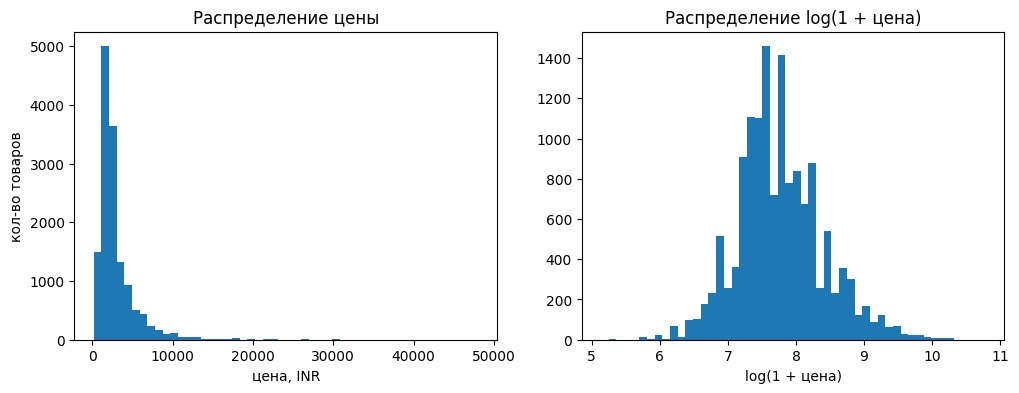

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(catalog['price'], bins=50)
ax[0].set_title('Распределение цены')
ax[0].set_xlabel('цена, INR')
ax[0].set_ylabel('кол-во товаров')

ax[1].hist(np.log1p(catalog['price']), bins=50)
ax[1].set_title('Распределение log(1 + цена)')
ax[1].set_xlabel('log(1 + цена)')
plt.show()

цены от 169 до 48 тыс рупий, медиана 2222 а среднее 2970 - распределение сильно скошено вправо, длинный хвост дорогих товаров. в логарифме форма почти симетричная, поэтому в регрессии будем предсказывать log цены а не саму цену - иначе хвост перетянет на себя весь лосс

In [10]:
catalog['brand'].nunique(), catalog['colour'].nunique()

(1022, 50)

In [11]:
catalog['brand'].value_counts().head(10)

brand
Roadster          346
Tokyo Talkies     284
MANGO             262
SASSAFRAS         242
URBANIC           232
Clora Creation    232
Mitera            204
Anouk             200
H&M               200
Dupatta Bazaar    171
Name: count, dtype: int64

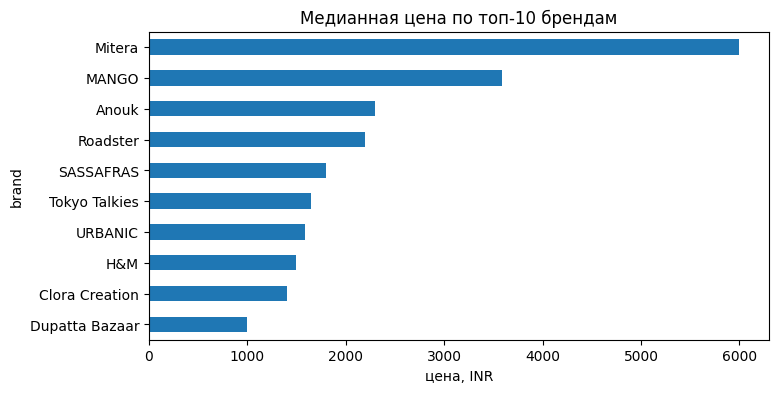

In [12]:
top_brands = catalog['brand'].value_counts().head(10).index
med_price = catalog[catalog['brand'].isin(top_brands)].groupby('brand')['price'].median()

med_price.sort_values().plot(kind='barh', figsize=(8, 4))
plt.title('Медианная цена по топ-10 брендам')
plt.xlabel('цена, INR')
plt.show()

брендов 1022, даже у самого крупного (Roadster) всего 346 товаров. one-hot на тысячу колонок делать не хочется, в ноутбуке 2 решим как кодировать - скорее всего топ-N брендов + other. а вот медианная цена между брендами отличается в разы, бренд явно один из главных признаков для цены

In [13]:
catalog['colour'].value_counts().head(10)

colour
Black        1901
Blue         1803
Pink         1170
Green        1082
Navy Blue     842
White         807
Red           707
Grey          571
Maroon        521
Yellow        496
Name: count, dtype: int64

In [14]:
catalog[['price', 'ratingCount', 'avg_rating']].corr().round(3)

,price,ratingCount,avg_rating
price,1.000,-0.049,-0.052
ratingCount,-0.049,1.000,0.029
avg_rating,-0.052,0.029,1.000


цветов 50, без перекосов - черный синий розовый в топе

с рейтингами неожиданно: цена практически не коррелирует ни с оценкой ни с числом отзывов, все корреляции около нуля. честно говоря ожидали что дорогие товары оцениваются лучше, но нет. значит рейтинги вряд ли сильно помогут модели, ставка на бренд категорию и атрибуты

ДАТАСЕТ С КАРТИНКАМИ: ПЕРВИЧНЫЙ ОСМОТР

второй датасет - 44 тыс карточек товаров с фото 80x60, разметка лежит в styles.csv

In [15]:
# часть строк битые (лишние запятые в названии товара), read_csv на них падает - скипаем
styles = pd.read_csv(os.path.join(images_path, 'styles.csv'), on_bad_lines='skip')
styles.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [16]:
styles.shape

(44424, 10)

In [17]:
styles.isna().sum()

id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64

из-за битых строк потеряли 22 строки из 44446 - не страшно. пропусков мало: немного в baseColour, season и usage, на разметке категорий (masterCategory / subCategory / articleType) пропусков нет вообще

In [18]:
styles['masterCategory'].value_counts()

masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64

In [19]:
styles['subCategory'].nunique(), styles['articleType'].nunique()

(45, 143)

In [20]:
styles['articleType'].value_counts().head(20)

articleType
Tshirts                  7067
Shirts                   3217
Casual Shoes             2845
Watches                  2542
Sports Shoes             2036
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   936
Flip Flops                914
Sandals                   897
Briefs                    849
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     613
Jeans                     609
Name: count, dtype: int64

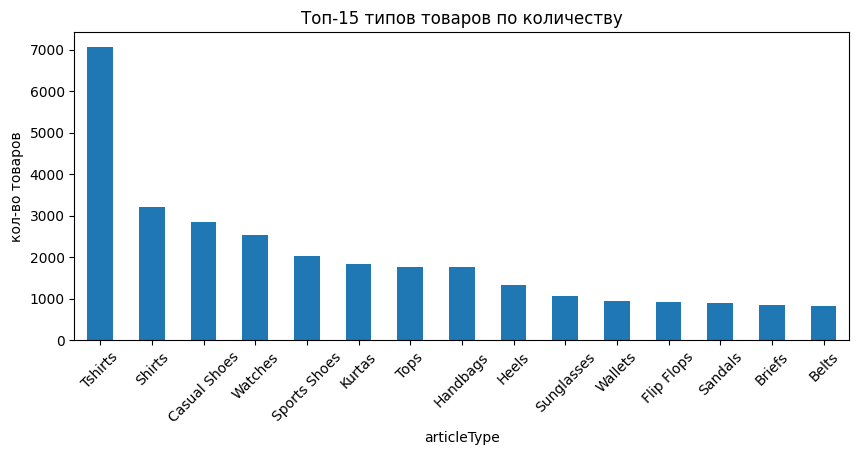

In [21]:
styles['articleType'].value_counts().head(15).plot(kind='bar', figsize=(10, 4))
plt.title('Топ-15 типов товаров по количеству')
plt.ylabel('кол-во товаров')
plt.xticks(rotation=45)
plt.show()

иерархия категорий трехуровневая: 7 masterCategory -> 45 subCategory -> 143 articleType. masterCategory сильно несбалансирован (от 21 тыс Apparel до 1 товара Home) и для бизнеса слишком грубый. articleType это как раз тот уровень который продавец выбирает в карточке, его и предсказываем

In [22]:
styles['gender'].value_counts()

gender
Men       22147
Women     18631
Unisex     2161
Boys        830
Girls       655
Name: count, dtype: int64

In [23]:
styles['usage'].value_counts().head()

usage
Casual          34406
Sports           4025
Ethnic           3208
Formal           2345
Smart Casual       67
Name: count, dtype: int64

In [24]:
img_files = os.listdir(os.path.join(images_path, 'images'))
len(img_files)

44441

In [25]:
img_ids = [int(f.split('.')[0]) for f in img_files]
(~styles['id'].isin(img_ids)).sum()

np.int64(5)

файлов с картинками 44441, и у 5 товаров из styles.csv файла нет - выкинем их при подготовке данных. посмотрим на сами фото

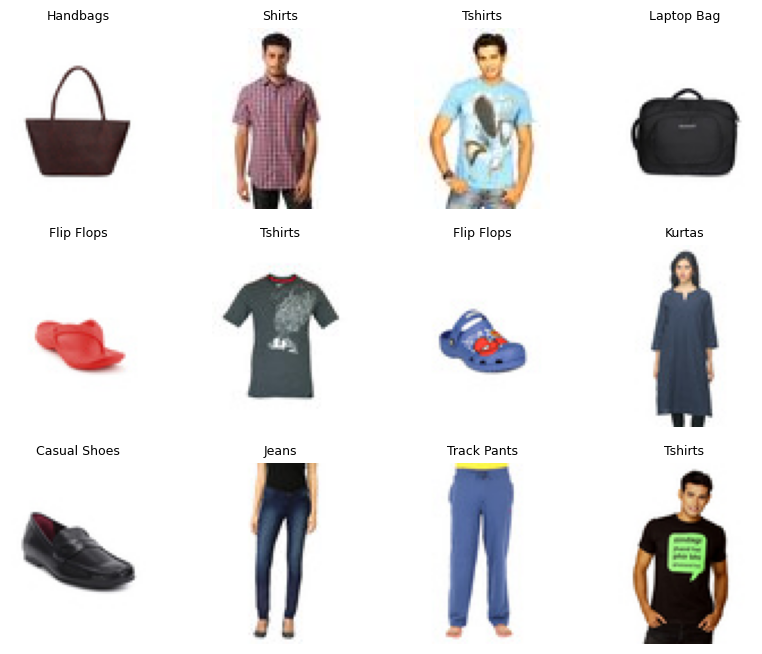

In [26]:
plt.figure(figsize=(10, 8))
sample = styles.sample(12, random_state=2026)
for i in range(12):
    plt.subplot(3, 4, i + 1)
    row = sample.iloc[i]
    img = plt.imread(os.path.join(images_path, 'images', str(row['id']) + '.jpg'))
    plt.imshow(img)
    plt.title(row['articleType'], fontsize=9)
    plt.axis('off')
plt.show()

фото маленькие (80x60) но категория опознается глазом легко: фон белый, товар по центру, ракурсы стандартные. для сети условия комфортные. правда разрешение низкое - посмотрим справятся ли архитектуры с мелкими отличиями типа сандалии против шлепанцев

In [27]:
top20 = styles['articleType'].value_counts().head(20)
round(top20.sum() / len(styles), 3)

np.float64(0.746)

классов 143, но хвост из совсем редких (по несколько товаров) - на них сеть не обучишь и для бизнеса они погоды не делают. топ-20 типов покрывают 74.6% каталога, классы от ~800 до 7 тыс примеров. в ноутбуке 3 берем классификацию на топ-20 articleType

ИТОГИ ЭТАПА 1

что сделали и что узнали:

- выбрали компанию (Myntra) и две связанные бизнес-задачи: рекомендация цены по атрибутам карточки (регрессия, полносвязная сеть) и определение категории по фото (классификация, CNN). обе - части одного пайплайна заведения товара на платформе
- данные получили автоматически через kagglehub, оба датасета - открытые выгрузки каталога Myntra
- каталог с ценами: 14214 товаров, дублей нет, пропуски только в рейтингах (54% товаров без оценок). таргет скошен вправо - предсказывать будем log цены. главный сюрприз: рейтинги с ценой не связаны, ставку делаем на бренд (1022 штуки, надо умно кодировать), цвет и атрибуты из p_attributes
- картинки: 44424 размеченных товара, у 5 нет файла фото. фото 80x60 на белом фоне, категория хорошо читается. для классификации берем топ-20 articleType - 74.6% каталога

дальше: ноутбук 2 - парсинг p_attributes, сборка признаков и сравнение конфигураций полносвязной сети; ноутбук 3 - сравнение CNN-архитектур на фото. все эксперименты - с логированием в wandb